# Assignment 4

When looking at uncertainties in modeling, beside the uncertainties in the parameters of the model, uncertainties in the model input also play are role in how the model is calibrating. In the case of hydrology and more specifically the HBV model these inputs are the precipitation of the observed catchment.

After quantifying the uncertainities of the parameters, we want to go a step further and analyze uncertainties arising from the model input, which also impacts the quality of model calibration. In our case, these inputs are the precipitation of the observed catchment.

## Why would the precipitation be uncertain?

First of all, the precipitation values we have are not the real-world values, but merely measured and therefore are impacted from precision of the measurement. Hydrological data, especially in a lumpded model, suffer from imprecision in measurement and day to day changes, which cannot be captured precisely. Yet, even if these factors are mitigated, there remains a certain level of noise.

Second, precipitaion in our lumpded model is measured at finitely many gauges and not over the total area. Althouh radars can measure a wider area, the data obtained is rather inaccurate and more used for local events, resulting in our data being provided by point measures, which can of course not cover literally every point in the catchment and so have to be distributed. The density of these measurements is naturally dependent on available money and thus varies between catchments. The result of having only a certain amount of data points available for a catchment area is obvious: A large portion of precipitation data for this area is unkown and has to be interpolated (If we wouldn't interpolate, our precipitation would be way too small for our catchment, resulting in wrong parameters). There are various ways to interpolate an area with given data points, however this is not the focus here. We rather want to focus on the precipitation value of the whole catchment that is already provided, in accordance with our conceptual and lumpded model.


## Methodology

In our case we have a time series spanning from the 1st of November 2010 to the 28th of February 2011 with a temporal resolution of one hour with a given reference precipitation pptn_ref. One can directly note that this time series generalizes poorly and may suffer from input uncertainty. Here is an excerpt of the first few values provided:




In [3]:
import pandas
dataframe = pandas.read_csv('time_series___24163005.csv', sep=';', nrows=10)
dataframe

,Unnamed: 0,tavg__ref,pptn__ref,petn__ref,diso__ref,ddho__ref
0,2010-11-01-00,7.649465,0.0,0.03566,4.21,163.0
1,2010-11-01-01,6.724136,0.0,0.03130,4.21,163.0
2,2010-11-01-02,6.004804,0.0,0.02802,4.21,163.0
3,2010-11-01-03,5.880548,0.0,0.02745,4.21,163.0
4,2010-11-01-04,5.305698,0.0,0.02464,4.21,163.0
5,2010-11-01-05,4.899967,0.0,0.02268,4.21,163.0
6,2010-11-01-06,4.836225,0.0,0.02240,4.21,163.0
7,2010-11-01-07,4.883360,0.0,0.02264,4.21,163.0
8,2010-11-01-08,6.138680,0.0,0.02860,4.21,163.0
9,2010-11-01-09,7.931963,0.0,0.03718,4.21,163.0


Now we want to perturb this time series. For the sake of simplicity we use a Gaussian distribution to create noise, which we then multiply with our original value. The lower bound is at 0, because precipitation can not be negative.

In [ ]:
noise = np.random.normal(1, 0.05, size=pptn.shape)
pptn_perturbed = np.maximum(noise * pptn, 0.0)

We compare the resulting cumulative distribution functions of the reference and perturbed precipitation as a validation. 



In [ ]:
def plot_cdf_precipitation_log(precip_ref, precip_perturbed, out_png):
    fig = plt.figure(figsize=(6, 4), dpi=120)
    sorted_ref = np.sort(precip_ref)
    sorted_perturbed = np.sort(precip_perturbed)
    p_ref = np.arange(1, len(sorted_ref) + 1) / len(sorted_ref)
    p_perturbed = np.arange(1, len(sorted_perturbed) + 1) / len(sorted_perturbed)
    plt.plot(sorted_ref, p_ref, label="Reference Precipitation", marker='o', linestyle='-', markersize=4)
    plt.plot(sorted_perturbed, p_perturbed, label="Perturbed Precipitation", marker='s', linestyle='--', markersize=4)
    plt.xlabel("Precipitation [mm/hr]")
    plt.ylabel("Cumulative Probability")
    plt.title("CDF of Precipitation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

We expect to observe similar cdf's due to the low noise level. As one can see in the following figure, the two graphs do not differentiate too much and larger value get perturbed much more.




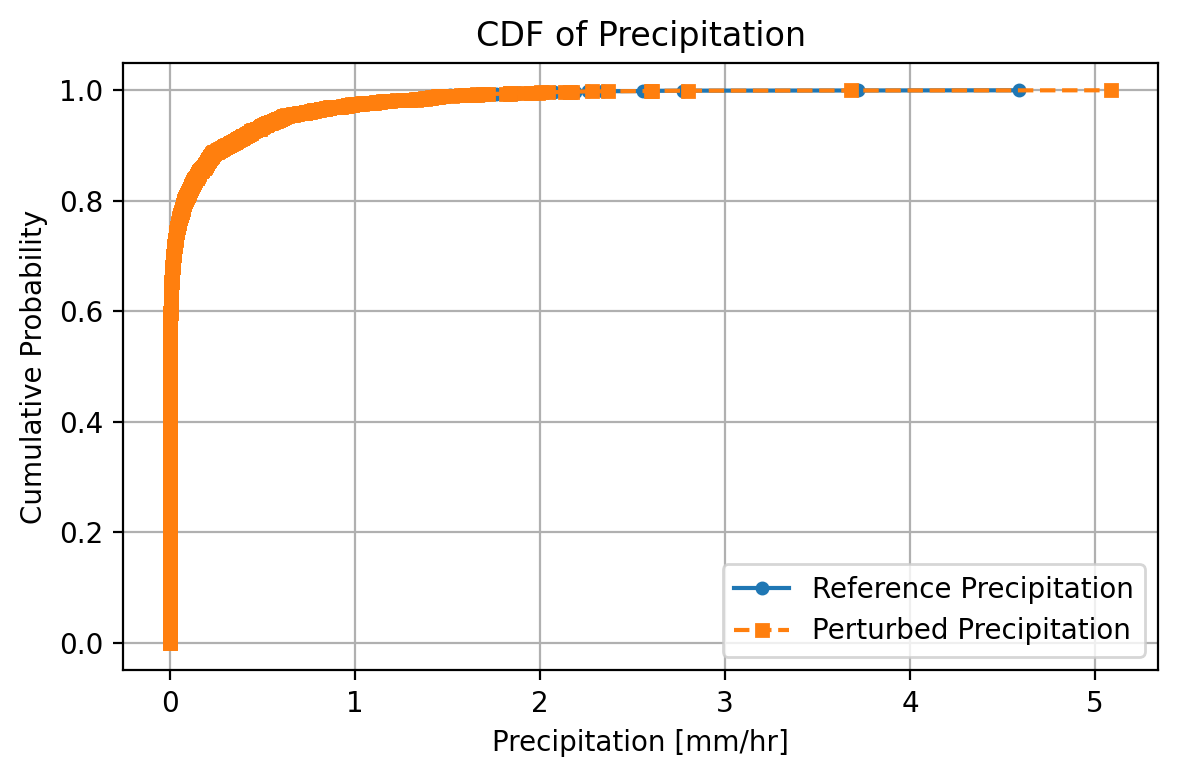

Now that we have verified our code, we can continue with our assessment and quantify input uncertainty.

We perturb the time series 2,000 times as described above such that we have 2,000 perturbed and one original time series. Since this is very memory consuming, we run the parallelized script 4 times with 500 simulations respectively. Next, with each of our 2,000 perturbed time series, we recalibrate the model with our code from assignment 1 resulting in a total of 2,001 parameter vectors; one for each perturbed series and the orginial one and especially the objective function value.

In [ ]:
best_params, best_ofv, best_metrics, best_sim = CalibrateModel(pptn_perturbed, ags, optn_args.modl_objt) 

We then let the reference parameters (i.e. the orginial parameter vector from assigment 1) run with the perturbed time series.

In [ ]:
q_fixed = optn_args.fast_model.run_model(pptn_perturbed, Best_Parameter_Assignment1)

As a result we have now 4,001 OFVs, two for each time series, resulting from one OFV from the reference parameters and one from the calibrated model and lastly the orginial OFV from assignment 1. 

We can now compare our results in plotting the OFVs of the reference parmeters against the calibrated parameters to see, how much the calibration alters the OFV.

In [ ]:
def plot_scatter_ofvs_precipitation(OFVs, OFVs_REF, out_png):
    fig = plt.figure(figsize=(6, 4), dpi=120)
    plt.scatter(OFVs, OFVs_REF, alpha=0.7)
    # Add the angle bisector (1:1 line)
    min_val = min(min(OFVs), min(OFVs_REF))
    max_val = max(max(OFVs), max(OFVs_REF))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 line (angle bisector)')
    plt.xlabel("OFV when recalibrating after perturbation")
    plt.ylabel("OFV when using parameters from assignment 1")
    plt.title("Scatterplot of OFVs")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

We can also plot the respective CDFs of the OFVs to see their shift.

In [ ]:
def plot_cdf_ofvs(ofvs_ref, ofvs_perturbed, out_png):
    fig = plt.figure(figsize=(6, 4), dpi=120)
    sorted_ref = np.sort(ofvs_ref) # sort the ofvs which you round to then count the individual values
    sorted_perturbed = np.sort(ofvs_perturbed)
    p_ref = np.arange(1, len(sorted_ref) + 1) / len(sorted_ref)  # Plus 1 as python counts from zero. Now count cumulative probabilities (obs i / total obs)
    p_perturbed = np.arange(1, len(sorted_perturbed) + 1) / (len(sorted_perturbed)+1) # verify if we have an integer division or not
    plt.plot(sorted_ref, p_ref, label="Reference Precipitation", marker='o', linestyle='-', markersize=4)
    plt.plot(sorted_perturbed, p_perturbed, label="Perturbed Precipitation", marker='s', linestyle='--', markersize=4)
    plt.xlabel("Objective Function Value (1 - NSE)")
    plt.ylabel("Cumulative Probability")
    plt.title("CDF of Objective Function Values")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Similarly, for each parameter a CDF can be plotted as well as a boxplot, effectively showing the same results.

In [ ]:
def plot_cdf_params(params_ref, params_perturbed, out_png):
    PARAM_NAMES = [
    "snw_dth","snw_att","snw_pmf","snw_amf",
    "sl0_dth","sl0_pwp","sl0_fcy","sl0_bt0",
    "urr_dth","lrr_dth",
    "urr_wsr","urr_ulc","urr_tdh","urr_tdr","urr_ndr","urr_uct",
    "lrr_dre","lrr_lct"
    ]
    fig, axs = plt.subplots(len(PARAM_NAMES), 1, figsize=(6, 3 * len(PARAM_NAMES)), dpi=120)
    for i, name in enumerate(PARAM_NAMES):
        #sorted_ref = np.sort(params_ref[:, i])
        sorted_pertubed = np.sort(params_perturbed[:, i])
        #p_ref = np.arange(1, len(sorted_ref) + 1) / len(sorted_ref)
        p_perturbed = np.arange(1, len(sorted_pertubed) + 1) / (1+len(sorted_pertubed))
        axs[i].axvline(x=params_ref[i], color='red', linestyle='--', label='Reference Parameter Value')
        #axs[i].plot(sorted_ref, p_ref, label="Reference Precipitation", marker='o', linestyle='-', markersize=4)
        axs[i].plot(sorted_pertubed, p_perturbed, label="Perturbed Precipitation", marker='s', linestyle='--', markersize=4)
        axs[i].set_xlabel(f"Parameter: {name}")
        axs[i].set_ylabel("Cumulative Probability")
        axs[i].set_title(f"CDF of {name}")
        axs[i].grid(True)
        axs[i].legend() 
    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    def boxplot_parameters_results(parameter_name, parameter_values, ref_parameter, out_png):
    for j in range(len(parameter_name)):
        fig = plt.figure(figsize=(10, 6), dpi=120)
        plt.boxplot([parameter_values[i][j] for i in range(len(parameter_values))], labels=[parameter_name[j]], showfliers=False)
        plt.scatter(1, ref_parameter[j], color='red', label='Reference Parameter', zorder=5)
        plt.xticks(rotation=90)
        plt.xlabel("Parameters")
        plt.ylabel("Parameter Value")
        plt.title(f"Boxplot of Parameter: {parameter_name[j]}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_png.replace(".png", f"_{parameter_name[j]}.png"), dpi=200, bbox_inches="tight")
        #plt.show()
        plt.close(fig)

For six randomly selected perturbed time series a hydrograph was plotted to get a better understanding of the effects in perturbing the time series.

In [ ]:
random_indices = np.random.choice(len(SimulationResults), 6, replace=False)
selected_sims = [SimulationResults[i] for i in random_indices]

plot_all_sim_obs(df.index, diso, selected_sims, "Observed Discharge and 6 Random Simulated Discharges", "Random_6_Simulations_Discharge.png")

Lastly for the plots, a survival function was created, showing the probablity of the precipitation values to reach a value.

In [ ]:
plot_survival_log_vs_reference(pptn_perturbed_all, optn_args.ppts.copy(), "survival_log_vs_reference.png")

## Results

Let's take a look on how these plots turned out. First let's see how the precipitation values look. Here is the reference precipitation:

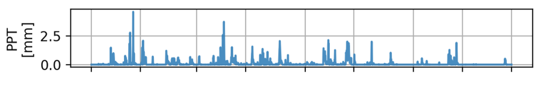

And here is the survival function of the perturbed values:

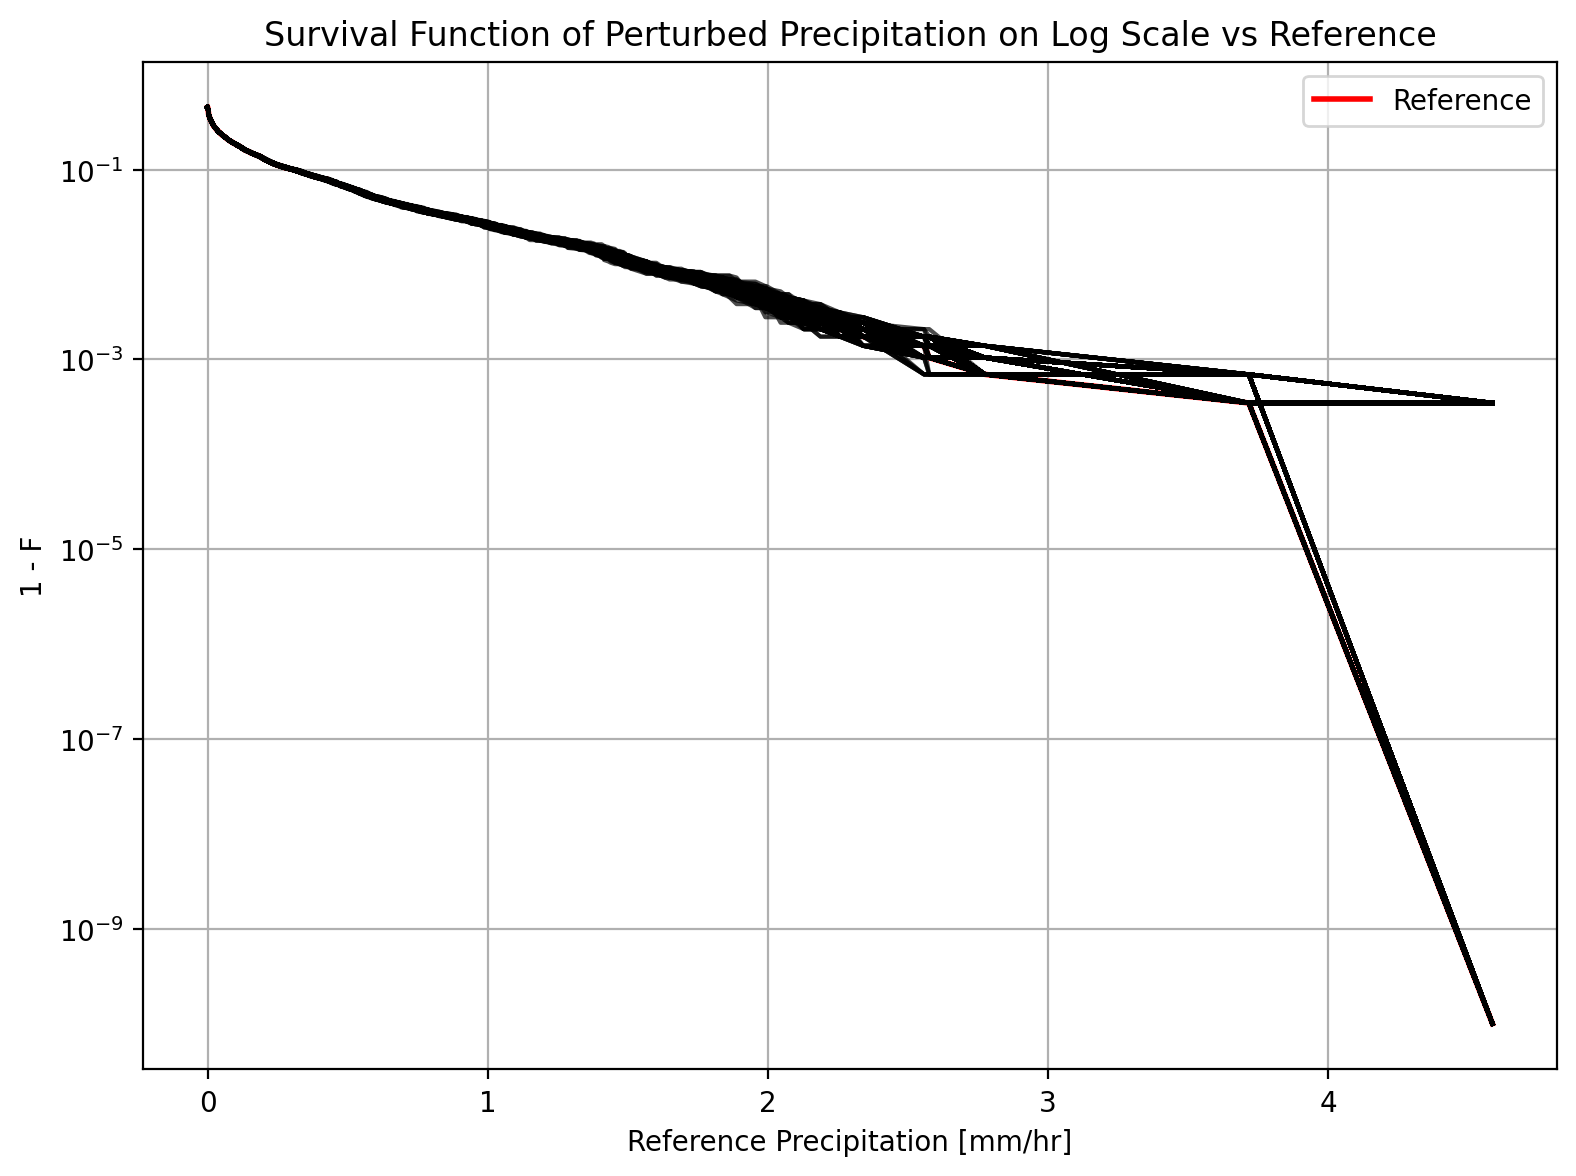

As already seen in the validation process in the beginning, the lower values dominate the time series.

Now we can take a look at the OFVs and see how they behave. 

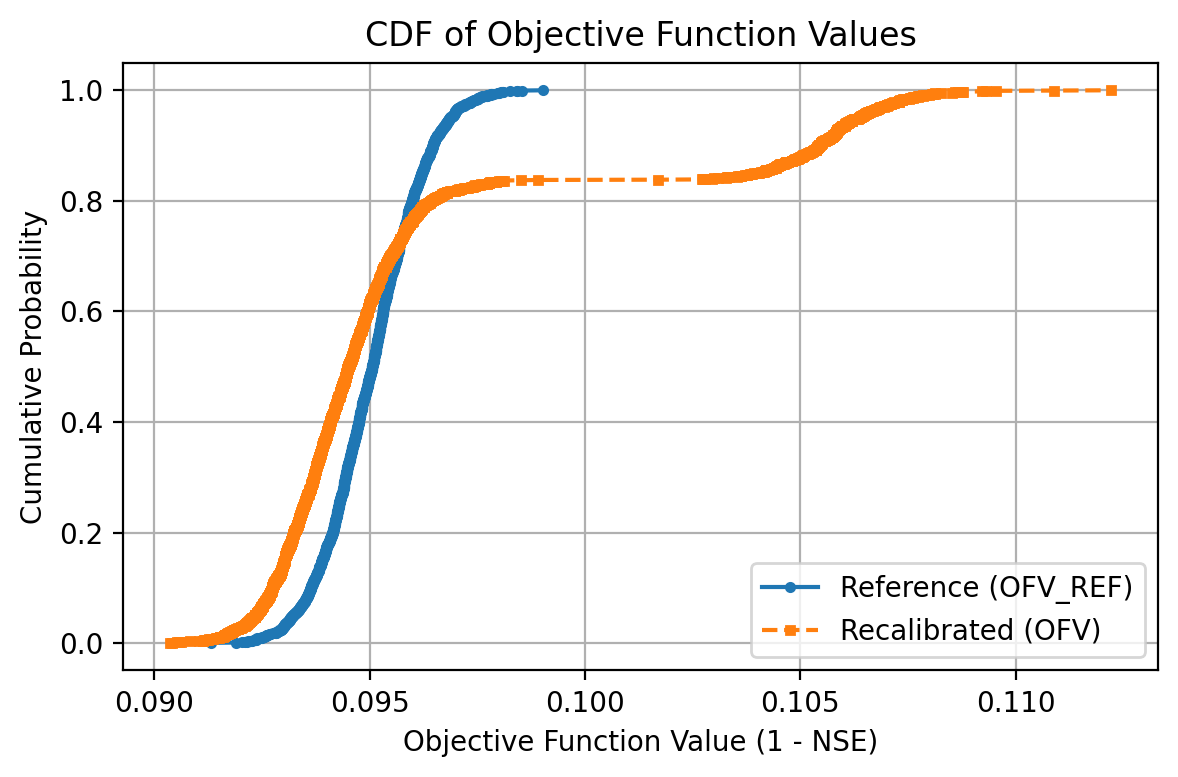

As expected the OFVs get better when recalibrating the model. Notably however is the plateau at around 0.1 OFV and the subsequent slope at around 0.107. This is probably due to a local minimum, from which the differential evolution can not escape. The same can be seen in the scatter plot:

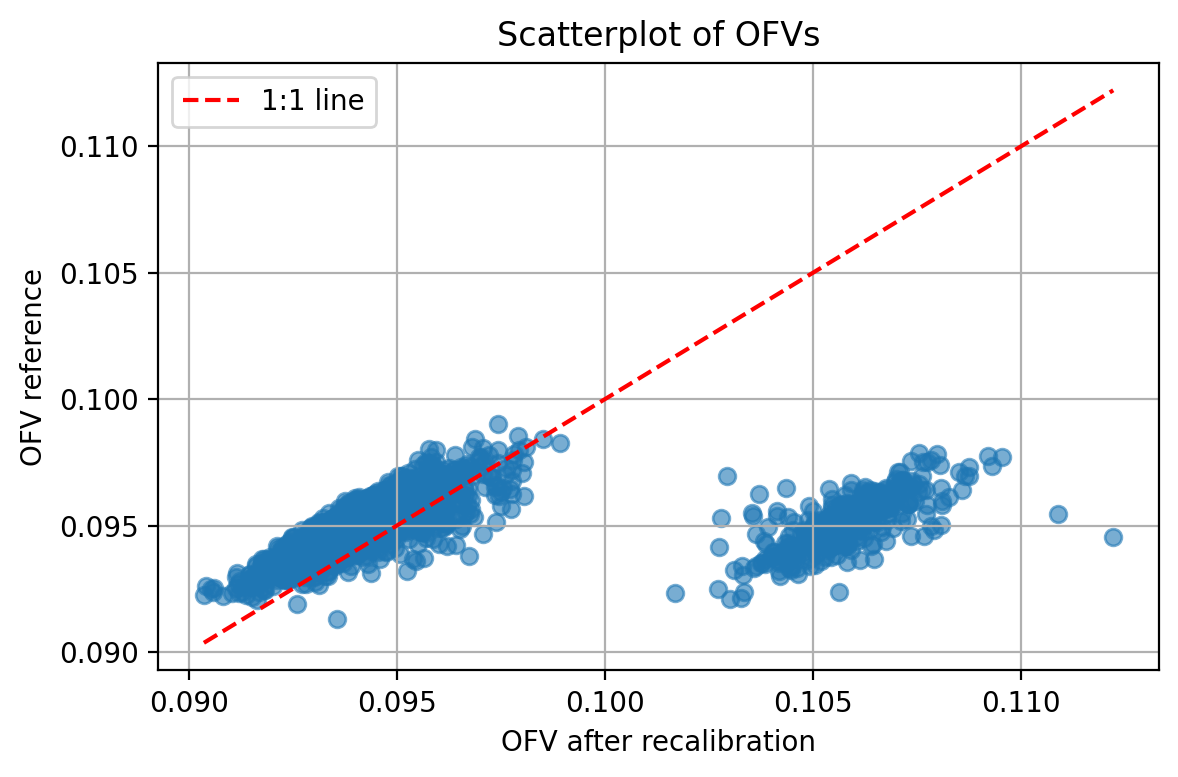

One would expect the recalibration to get always a better, or at least the same, result, which is indicated by a point being above the bisector. The group on the lower right corner therefore is due to the same minimum as in the CDF plot. The effect of this local minima can be mitigated by changing the settings of the differential evolution algorithm to increase the likelihood of escaping it, which then looks like this:

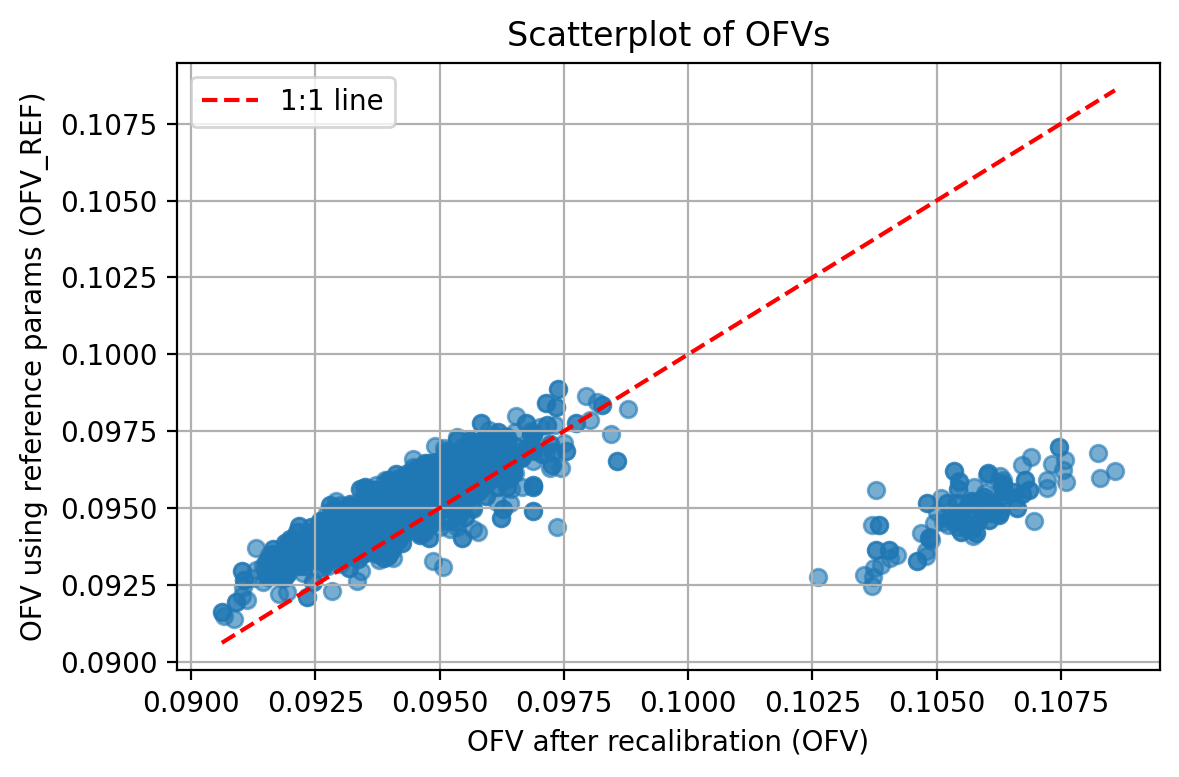

The boxplots for the parameters show the following result:

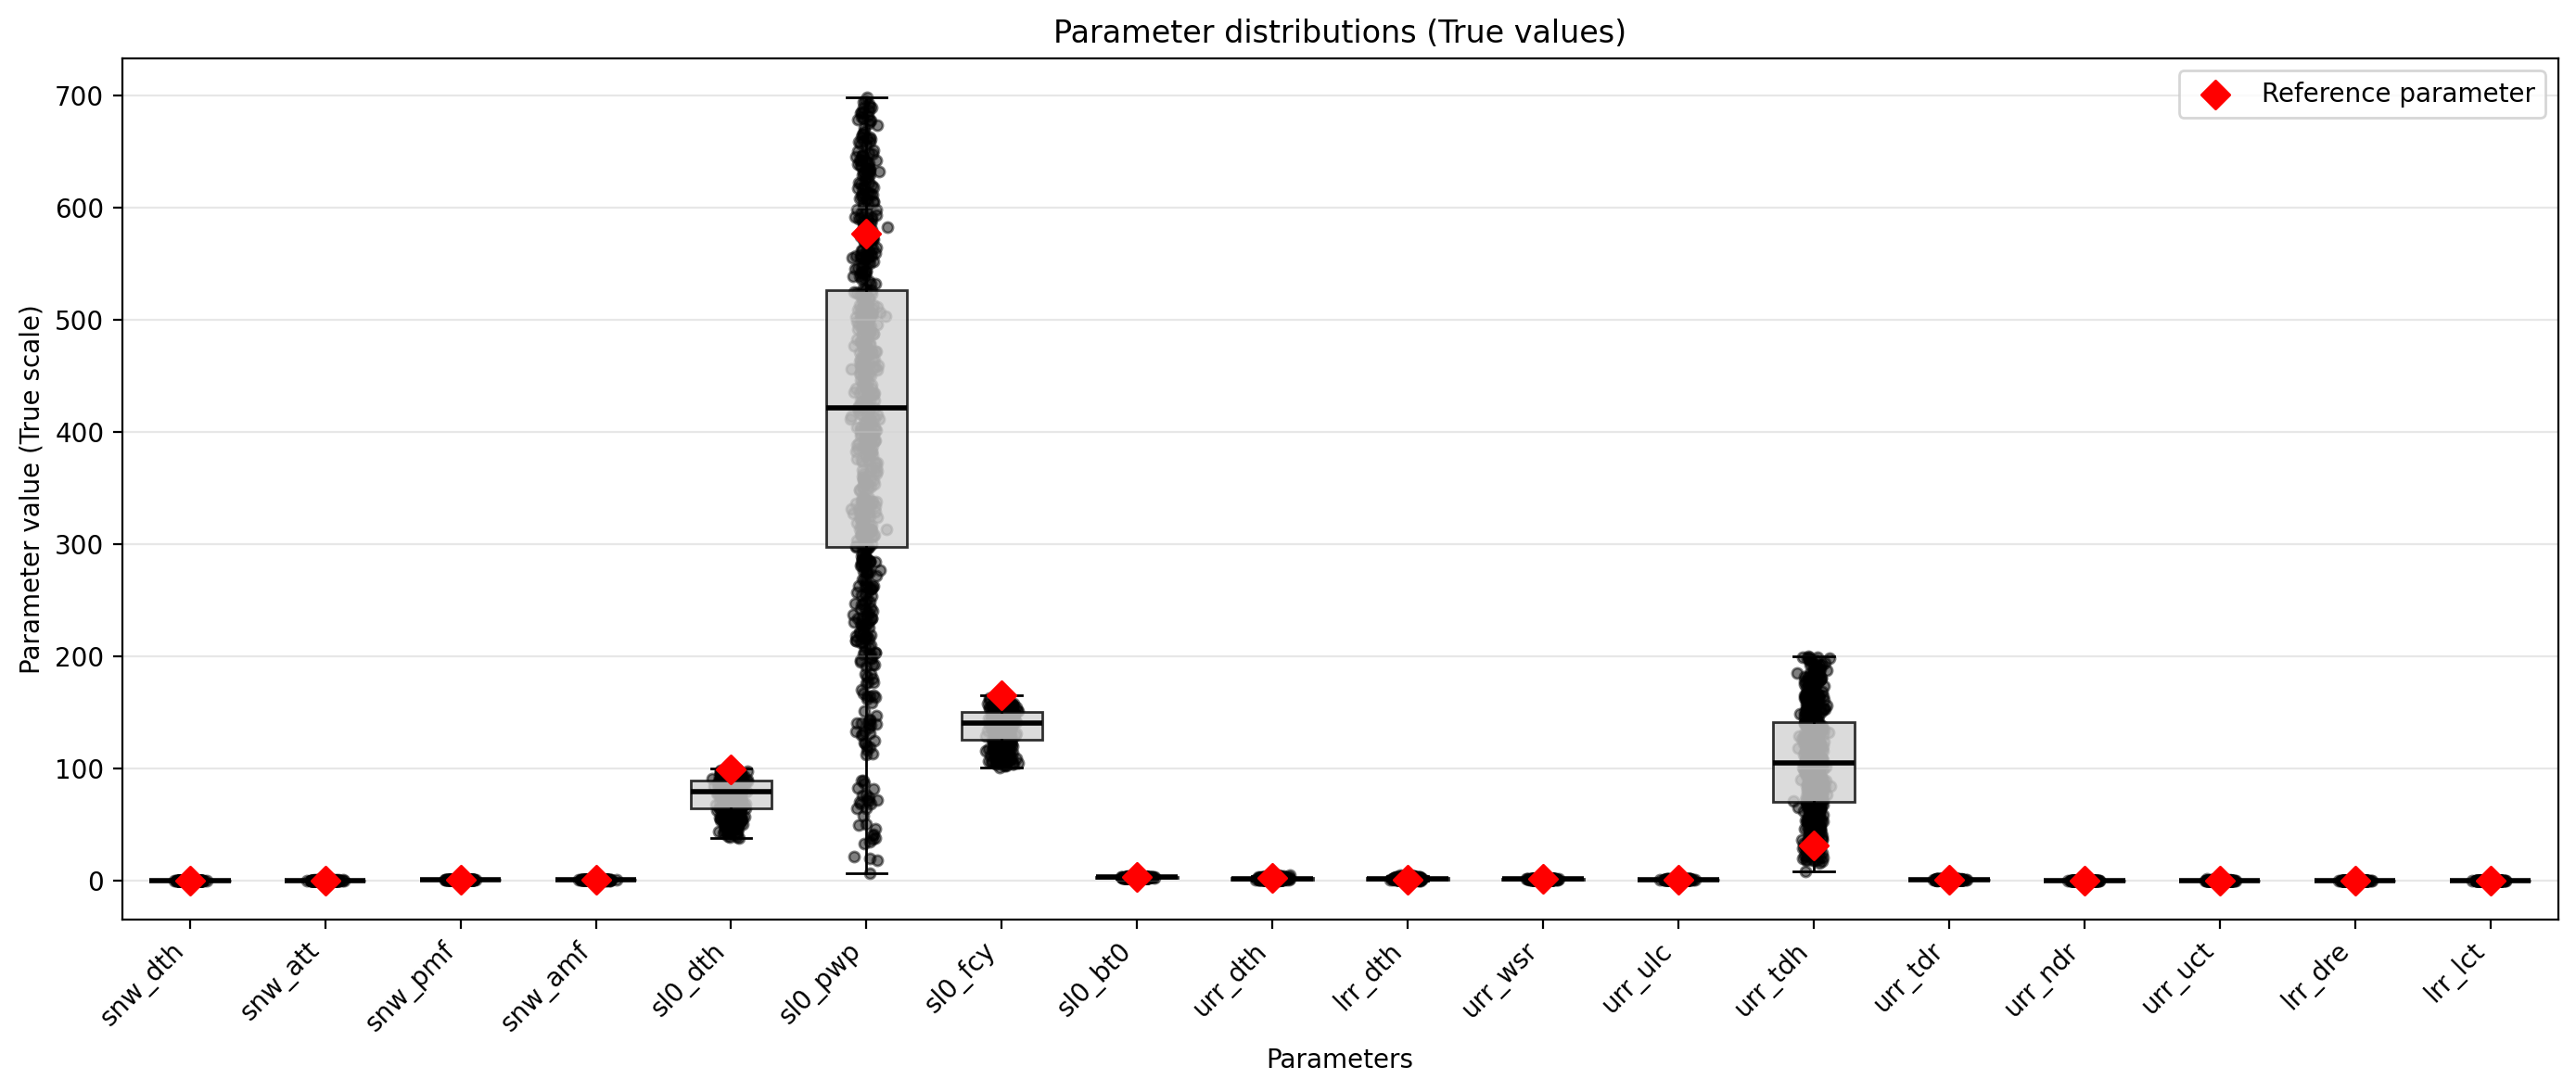

Because most parameters lie close to zero their behaviour is hard to assess only from this plot, what can be seen however is that the permanent wilting point covers almost its entire range of possible values (5 to 700) pretty homogeneously, only samller values below 200 and especially below 100 show a lower probability.

When looking at the plots of the CDFs one can see that there are differences in their shape. For example, parameters that have a constant slope have a more uniform distribution and point to a lesser sensitivity.

![Screenshot 2026-03-13 133107.png](<attachment:Screenshot 2026-03-13 133107.png>)

![Screenshot 2026-03-13 134952.png](<attachment:Screenshot 2026-03-13 134952.png>)

Others show a steeper slope with a tighter distribution, which points to a higher senisitvity.

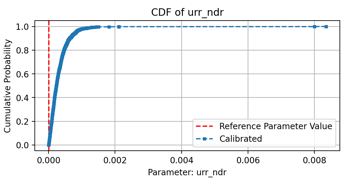

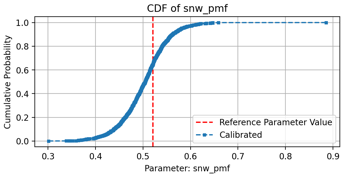

## Connection to other assignments

One needs to truly understand that in this assignment we consider input uncertainty and hence the sensitivity term changes compared to the previous assignments is a new one. Before, we assumed that we have the true data and wanted to investigate how sensitive in the model themselves are assuming we found the global optimum in assignment 1. In this exercise, we accounted for probable measurement errors and natural imprecisions of measuring precipitation. We then wanted to examine how well the model can compensate for this uncertainty, meaning that we can incorporate input uncertainty in model useage and interpretation. In addition, when looking at the cdf's and boxplots we are able to tell how the individual parameters are affected by the noise introduced, that is how sensitive they are w.r.t. input uncertainty.

Generally speaking, we saw that the model can truly compensate for the input uncertainty, as the OFV are lower (see scatterplot) and the cdf of OFV of recalibrated runs dominate the uncalibrated one. Hence, we conclude that our model does account for input uncertainty. How about the individual parameters?

Before looking in detail at a few parameters, let's discuss how we would analyze the cdf plots and boxplots. First, the position of the reference parameter tells us how biased the model behaves. That is, if the reference parameter is perfectly at the 0.5 quantile, the parameter would be robust against the added noise. If it is in extreme quantiles like the 0.05, this means that the noise added changed the parameter values drastically. Further analysis is due. The boxplots help us to see if the reference parameter is an extreme case and hence the parameter is sensitive to input uncertainty or to be precise how biased the model is. Second, the slope of the cdf tells us more about the sensitivity. A very steep vertical rise indicates that despite the input noise, the recalibrated parameter stays within a very narrow range. On the other hand, a fat slope would mean the parameter is highly sensitive to input uncertainty. Roughly speaking, if the data is slightly wrong, the parameter value could be almost anything. Finally, the tail behaviour tells us how likely outliers were. It tells you if your input is terribly off, how likely we get a parameter that is off to the expected cases. If outliers are probable, the parameter is even more sensitive wrt input uncertainty.

This analysis can then be combined to get a big and detailled picture of the different sensitivities of each parameters. How are they affected by local perturbations (assignment 2)? How do they interacts and vary if we vary all (assignment 3)? How do they react to input noise (assignemnt 4)?
### Snow module:

Snow threshold:
In previous assigments the fall/melt temperature treshold is sensitive in accordance with the pyhsical interpretation: This makes sense given that the temperature is bavaria as well as in the time series during the winter is around this temperature. 

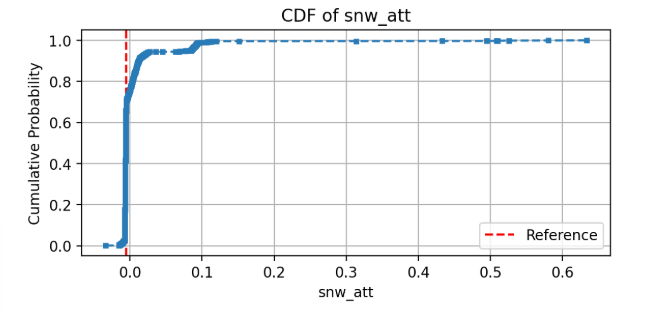

We observe a very steep slope, a few outliers and a reference parameter which is in the lower quantiles. As explained above, this indicates sensitivity wrt. input noise.

If we consider for instance the precipitation melt factor, we observe the converse:

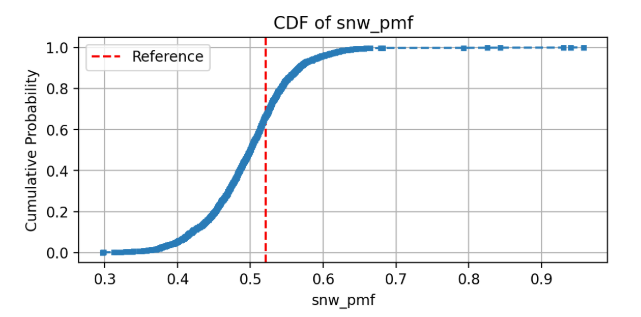

The reference is approximately in th 0.6 quantile, The slope is s-shaped and we have only a few outliers. It is less sensitive.

### Soil module:

UNSURE
When it comes to the soil parameters they all seem to be rather insensitive when perturbing the precipitation. This is actually in contrast to the previous assignments in reagrds to the field capacity and the soil beta. This can be explained by the different effects that chnaging precipitation and the parameters have. 

Field capacity
It is also important to know that parameters like the field capacity seem to be relativly insensitive, however, the upper bound in this case 700 is not nearly reached, instead it seems to be around 170. Given that the field capacity is intertwined, often by ratios, with the soil depth in the HBV model it is possible that they can change, when the other changes.

### Upper reservoir

Given the low impact of the upper reservoir it is not surprising that the paramters here are rather insensitive, except for the upper to lower constant, which dictates the percolation. This is supported by the other assignments.

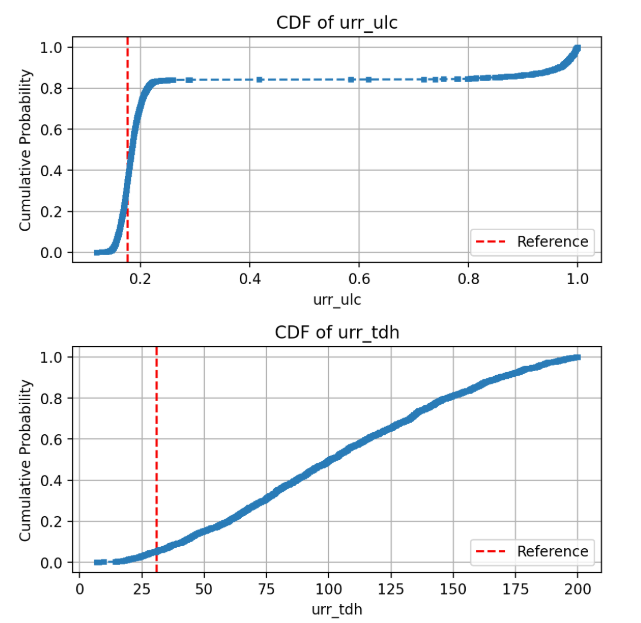

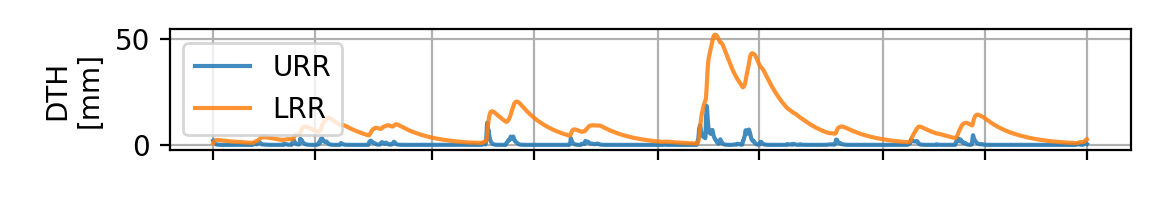

### lower reservoir

Like for the other depths, the initial lower reservoir depth is insensitive because this value can change over time and is not fixed. The other paramters however are sensitive, because of the importance of the lower reservoir, which could also be seen in previous assignments.

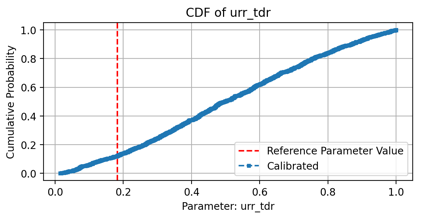
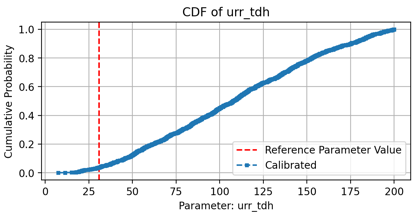